# Site-level juvenile growth analysis

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import statsmodels.api as sm

# Read data sets
counts = pd.read_csv("CTR_Juvenile_ASD_Master.csv")
lengths = pd.read_csv("Juvenile_Master_Length_Data_1978_2021.csv")

# Clean column names
counts.columns = counts.columns.str.strip()
lengths.columns = lengths.columns.str.strip()

# Define site groups
upper_sites = ["HOLYOKE", "ENFIELD", "WILSON"]

lower_sites = [
    "GLASTONBURY",
    "DEEP RIVER",
    "SALMON RIVER",
    "ESSEX"
]

# Clean counts data
counts["ASD_Count"] = pd.to_numeric(counts["ASD_Count"], errors="coerce")
counts["Temp"] = pd.to_numeric(counts["Temp"], errors="coerce")
counts["Month"] = pd.to_numeric(counts["Month"], errors="coerce")

counts["Site"] = (
    counts["Site"]
    .astype(str)
    .str.upper()
    .str.strip()
)

counts = counts[counts["Month"].isin([7, 8, 9])].copy()

# Clean lengths data
lengths["Length"] = pd.to_numeric(lengths["Length"], errors="coerce")
lengths["Month"] = pd.to_numeric(lengths["Month"], errors="coerce")
lengths["Date"] = pd.to_datetime(lengths["Date"], errors="coerce")
lengths["DOY"] = lengths["Date"].dt.dayofyear

lengths["Site"] = (
    lengths["Site"]
    .astype(str)
    .str.upper()
    .str.strip()
)

lengths = lengths[lengths["Month"].isin([7, 8, 9])].copy()

# Assign regions
def assign_region(site):
    if site in upper_sites:
        return "UPPER"
    elif site in lower_sites:
        return "LOWER"
    else:
        return np.nan

counts["Region"] = counts["Site"].apply(assign_region)
lengths["Region"] = lengths["Site"].apply(assign_region)

# Diagnostics
print("Counts missing values:")
print(counts[["ASD_Count", "Temp", "Month", "Site", "Region"]].isna().sum())

print("\nLengths missing values:")
print(lengths[["Length", "Date", "DOY", "Month", "Site", "Region"]].isna().sum())

print("\nUnmatched count sites:")
print(counts[counts["Region"].isna()]["Site"].unique())

print("\nUnmatched length sites:")
print(lengths[lengths["Region"].isna()]["Site"].unique())

/Users/viktoriasavatorova/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,
/Users/viktoriasavatorova/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,


Counts missing values:
ASD_Count      0
Temp         451
Month          0
Site           0
Region        10
dtype: int64

Lengths missing values:
Length    0
Date      0
DOY       0
Month     0
Site      0
Region    0
dtype: int64

Unmatched count sites:
['ROCKY HILL']

Unmatched length sites:
[]


# Compute site-year abundance, temperature, and growth

## Helper functions to compute (1) geometric mean abundance index, (2) mean temp and (3) estimated seasonal growth for each (Year x Site)

In [2]:
# ============================================================
# FUNCTIONS
# ============================================================

def gm_plus1(x):
    return np.exp(np.mean(np.log(x + 1))) - 1


def annual_gm_index_site(data, min_samples=10):
    data = data.dropna(subset=["ASD_Count"]).copy()

    result = (
        data.groupby(["Year", "Site"])
        .agg(
            GM_Index=("ASD_Count", gm_plus1),
            N_count_samples=("ASD_Count", "count")
        )
        .reset_index()
        .sort_values(["Site", "Year"])
    )

    result = result[result["N_count_samples"] >= min_samples].copy()
    return result


def annual_mean_temperature_site(data, min_samples=10):
    data = data.dropna(subset=["Temp"]).copy()

    result = (
        data.groupby(["Year", "Site"])
        .agg(
            Mean_Temp=("Temp", "mean"),
            N_temp_samples=("Temp", "count")
        )
        .reset_index()
        .sort_values(["Site", "Year"])
    )

    result = result[result["N_temp_samples"] >= min_samples].copy()
    return result


def compute_growth_site(data, min_samples=30, min_doy=10):
    data = data.dropna(subset=["Length", "DOY"]).copy()

    records = []

    for (year, site), dy in data.groupby(["Year", "Site"]):
        if len(dy) >= min_samples and dy["DOY"].nunique() >= min_doy:
            fit = linregress(dy["DOY"], dy["Length"])

            records.append({
                "Year": year,
                "Site": site,
                "Growth_mm_per_day": fit.slope,
                "Slope_SE": fit.stderr,
                "N_growth": len(dy),
                "N_DOY": dy["DOY"].nunique(),
                "Intercept": fit.intercept,
                "R_value": fit.rvalue,
                "P_value": fit.pvalue
            })

    result = pd.DataFrame(records).sort_values(["Site", "Year"]).reset_index(drop=True)
    return result

In [3]:
# ============================================================
# SITE-YEAR SUMMARIES
# ============================================================

# For each site and year,determine what was the abundance, what was the temperature,and what was the growth rate

gm_site = annual_gm_index_site(counts, min_samples=10)
temp_site = annual_mean_temperature_site(counts, min_samples=10)
growth_site = compute_growth_site(lengths, min_samples=30, min_doy=5)

print("\nGM site-level:")
print(gm_site.head())

print("\nTemperature site-level:")
print(temp_site.head())

print("\nGrowth site-level:")
print(growth_site.head())

print("GM rows:", gm_site.shape)
print("Temp rows:", temp_site.shape)
print("Growth rows:", growth_site.shape)


print(growth_site["Site"].unique())

print(growth_site.groupby("Site").size())



GM site-level:
    Year        Site  GM_Index  N_count_samples
5   1979  DEEP RIVER  7.373092               10
10  1980  DEEP RIVER  2.720395               10
16  1981  DEEP RIVER  6.029009               11
23  1982  DEEP RIVER  3.064206               10
30  1983  DEEP RIVER  0.788789               11

Temperature site-level:
    Year        Site  Mean_Temp  N_temp_samples
0   1983  DEEP RIVER  26.909091              11
7   1985  DEEP RIVER  25.545455              11
13  1986  DEEP RIVER  23.909091              11
20  1987  DEEP RIVER  23.500000              12
27  1988  DEEP RIVER  26.500000              12

Growth site-level:
   Year        Site  Growth_mm_per_day  Slope_SE  N_growth  N_DOY  Intercept  \
0  1979  DEEP RIVER           0.376445  0.050709        99     10 -25.573524   
1  1980  DEEP RIVER           0.283583  0.053026        51      8   9.165729   
2  1981  DEEP RIVER           0.225616  0.026812       105     10  16.022380   
3  1982  DEEP RIVER           0.649651  0.0

In [4]:
# =========================================================================================
# MERGE SITE-LEVEL DATA
# =========================================================================================

# Determine which site-years have growth, abundance, and temperature all available together

growth_abundance_site = (
    growth_site
    .merge(
        gm_site[["Year", "Site", "GM_Index"]],
        on=["Year", "Site"],
        how="inner"
    )
    .merge(
        temp_site[["Year", "Site", "Mean_Temp"]],
        on=["Year", "Site"],
        how="inner"
    )
    .sort_values(["Site", "Year"])
    .reset_index(drop=True)
)

print("\nMerged dataset — SITE level")
print(growth_abundance_site.head())
print("\nNumber of site-year observations:", len(growth_abundance_site))
print("\nSites in merged dataset:")
print(growth_abundance_site["Site"].value_counts())


Merged dataset — SITE level
   Year        Site  Growth_mm_per_day  Slope_SE  N_growth  N_DOY  Intercept  \
0  1986  DEEP RIVER           0.272999  0.024545       139     11  -8.650843   
1  1987  DEEP RIVER           0.468859  0.024256       189     12 -48.175672   
2  1988  DEEP RIVER           0.386285  0.054220        33     10 -24.744094   
3  1989  DEEP RIVER           0.438112  0.044292       198     12 -43.399115   
4  1990  DEEP RIVER           0.339215  0.024650       253     11 -24.566688   

    R_value       P_value   GM_Index  Mean_Temp  
0  0.688840  7.087533e-21   6.029797  23.909091  
1  0.816361  1.856118e-46  11.068309  23.500000  
2  0.787926  5.254519e-08   1.917408  26.500000  
3  0.577036  5.701679e-19  13.694003  25.000000  
4  0.655768  1.745743e-32  19.637247  24.454545  

Number of site-year observations: 177

Sites in merged dataset:
SALMON RIVER    32
WILSON          32
DEEP RIVER      31
HOLYOKE         27
ESSEX           22
GLASTONBURY     22
ENFIELD    

In [13]:
# TEMPORAL COVERAGE OF THE MERGED DATASET

# Report the range of years and the number of usable site-year
# observations retained after merging growth, abundance, and
# temperature data.

print(
    "Merged dataset years:",
    int(growth_abundance_site["Year"].min()),
    "-",
    int(growth_abundance_site["Year"].max())
)

print(
    "\nNumber of usable site-year observations per year:"
)

print(
    growth_abundance_site
    .groupby("Year")
    .size()
    .tail(15)
)

Merged dataset years: 1986 - 2019

Number of usable site-year observations per year:
Year
2005    6
2006    4
2007    6
2008    3
2009    5
2010    6
2011    3
2012    4
2013    5
2014    6
2015    6
2016    5
2017    6
2018    7
2019    5
dtype: int64


In [14]:
# Count the number of usable site-year observations for each site.
# Sites with very few observations may produce unstable estimates,
# so we retain only sites with at least 10 usable site-year records.

site_counts = (
    growth_abundance_site
    .groupby("Site")
    .size()
)

print(site_counts)

valid_sites = site_counts[site_counts >= 10].index

#growth_abundance_site_filtered = (
#    growth_abundance_site[
#        growth_abundance_site["Site"].isin(valid_sites)
#    ]
#)


growth_abundance_site_filtered = (
    growth_abundance_site[
        growth_abundance_site["Site"].isin(valid_sites)
    ].copy()
)



print("\nFiltered dataset size:",
      len(growth_abundance_site_filtered))

print("\nSites retained:")
print(growth_abundance_site_filtered["Site"].value_counts())

Site
DEEP RIVER      31
ENFIELD         11
ESSEX           22
GLASTONBURY     22
HOLYOKE         27
SALMON RIVER    32
WILSON          32
dtype: int64

Filtered dataset size: 177

Sites retained:
SALMON RIVER    32
WILSON          32
DEEP RIVER      31
HOLYOKE         27
ESSEX           22
GLASTONBURY     22
ENFIELD         11
Name: Site, dtype: int64


In [15]:
# Summary statistics for the main variables used in the analysis.
# Note that GM_Index is strongly right-skewed, which motivates using a log transformation in the regression model.

growth_abundance_site_filtered[
    ["Growth_mm_per_day", "GM_Index", "Mean_Temp"]
].describe()


,Growth_mm_per_day,GM_Index,Mean_Temp
count,177.000000,177.000000,177.000000
mean,0.415698,26.582186,24.384933
std,0.166735,72.433103,1.447847
min,0.016656,1.026610,20.500000
25%,0.310271,4.197662,23.400000
50%,0.398433,9.576238,24.454545
75%,0.515070,23.255484,25.363636
max,0.914891,734.292945,28.333333


# Fit multiple regression model

In [16]:
# Multiple linear regression model relating juvenile growth
# to abundance, temperature, and site.
#
# C(Site) treats Site as a categorical variable and estimates
# site-specific differences in growth after accounting for
# abundance and temperature.

import statsmodels.formula.api as smf

model_site = smf.ols(
    "Growth_mm_per_day ~ GM_Index + Mean_Temp + C(Site)",
    data=growth_abundance_site_filtered
).fit()

print(model_site.summary())

                            OLS Regression Results                            
Dep. Variable:      Growth_mm_per_day   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     2.543
Date:                Thu, 27 Aug 2026   Prob (F-statistic):             0.0122
Time:                        13:57:47   Log-Likelihood:                 76.532
No. Observations:                 177   AIC:                            -135.1
Df Residuals:                     168   BIC:                            -106.5
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [17]:
# # Because GM_Index is strongly right-skewed, we also fit a model using log-transformed abundance.


growth_abundance_site_filtered["log_GM"] = np.log1p(
    growth_abundance_site_filtered["GM_Index"]
)

model_site_log = smf.ols(
    "Growth_mm_per_day ~ log_GM + Mean_Temp + C(Site)",
    data=growth_abundance_site_filtered
).fit()

print(model_site_log.summary())

                            OLS Regression Results                            
Dep. Variable:      Growth_mm_per_day   R-squared:                       0.110
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     2.600
Date:                Thu, 27 Aug 2026   Prob (F-statistic):             0.0105
Time:                        13:57:57   Log-Likelihood:                 76.748
No. Observations:                 177   AIC:                            -135.5
Df Residuals:                     168   BIC:                            -106.9
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

# Compare growth among sites

In [18]:
# Kruskal–Wallis test:nonparametric comparison of growth distributions across sites.
# This test evaluates whether at least one site differs in median/rank distribution from the others.

from scipy.stats import kruskal

groups = [
    group["Growth_mm_per_day"].values
    for name, group in growth_abundance_site_filtered.groupby("Site")
]

result = kruskal(*groups)

print("\nKruskal–Wallis test — Growth across sites")

print("Statistic:", result.statistic)
print("p-value:", result.pvalue)




Kruskal–Wallis test — Growth across sites
Statistic: 14.797446382124576
p-value: 0.021892002553853148


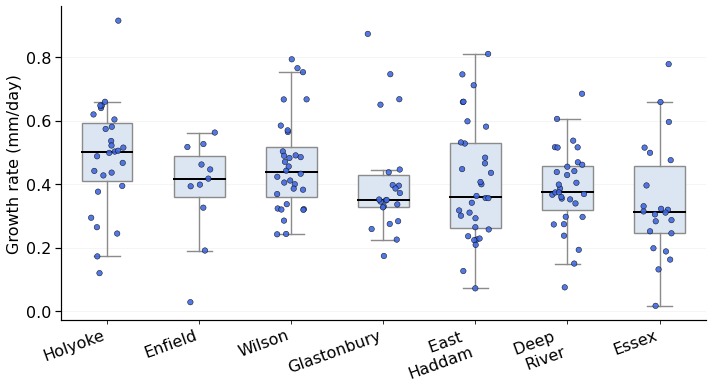

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# SITE ORDER: NORTH TO SOUTH
# The names here must exactly match the values in the Site column
# ============================================================

site_order = [
    "HOLYOKE",
    "ENFIELD",
    "WILSON",
    "GLASTONBURY",
    "SALMON RIVER",
    "DEEP RIVER",
    "ESSEX"
]

# ============================================================
# DISPLAY LABELS
# Change any label here without modifying the dataframe
# ============================================================

site_labels = {
    "HOLYOKE": "Holyoke",
    "ENFIELD": "Enfield",
    "WILSON": "Wilson",
    "GLASTONBURY": "Glastonbury",
    "SALMON RIVER": "East \nHaddam",
    "DEEP RIVER": "Deep \nRiver",
    "ESSEX": "Essex"
}

# ============================================================
# PUBLICATION-QUALITY BOXPLOT
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5.5))

sns.boxplot(
    data=growth_abundance_site_filtered,
    x="Site",
    y="Growth_mm_per_day",
    order=site_order,
    width=0.55,
    linewidth=1.4,
    color="#DCE6F2",
    #color="lightsteelblue",
    saturation=1,
    showfliers=False,
    medianprops=dict(
        color="black",
        linewidth=2
    ),
    ax=ax
)


sns.stripplot(
    data=growth_abundance_site_filtered,
    x="Site",
    y="Growth_mm_per_day",
    order=site_order,
    color="royalblue",
    edgecolor="black",
    linewidth=0.5,
    alpha=0.9,
    jitter=0.18,
    size=5.5,
    ax=ax
)

# Axis labels
ax.set_xlabel("", fontsize=16)
ax.set_ylabel("Growth rate (mm/day)", fontsize=16)

# Replace the displayed site names
ax.set_xticks(range(len(site_order)))
ax.set_xticklabels(
    [site_labels[site] for site in site_order],
    rotation=20,
    ha="right",
    fontsize=16
)

ax.tick_params(
    axis="y",
    which="major",
    labelsize=16,
    width=1.2,
    length=6
)

# Optional light horizontal grid only
ax.grid(
    axis="y",
    alpha=0.15,
    linewidth=0.8
)

ax.set_axisbelow(True)

# Thicker visible axes
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# Usually omit the title for a journal figure
# ax.set_title(
#     "Distribution of juvenile growth rates by site",
#     fontsize=16
# )

sns.despine(ax=ax)

fig.tight_layout()

fig.savefig(
    "growth_across_sites_kw.pdf",
    bbox_inches="tight"
)

plt.show()

In [20]:
# Post hoc Dunn's test for pairwise site comparisons following a significant Kruskal–Wallis result.
# The Holm correction adjusts p-values for multiple comparisons to reduce the chance of false positives.
# "fdr_bh" is an alternative correction which is often less conservative. Here we use the Holm correction.


import scikit_posthocs as sp

dunn_results = sp.posthoc_dunn(
    growth_abundance_site_filtered,
    val_col="Growth_mm_per_day",
    group_col="Site",
    #p_adjust="fdr_bh"
    p_adjust="holm"
)

print(dunn_results)

              DEEP RIVER  ENFIELD     ESSEX  GLASTONBURY   HOLYOKE  \
DEEP RIVER      1.000000      1.0  1.000000     1.000000  0.493807   
ENFIELD         1.000000      1.0  1.000000     1.000000  1.000000   
ESSEX           1.000000      1.0  1.000000     1.000000  0.023883   
GLASTONBURY     1.000000      1.0  1.000000     1.000000  0.518058   
HOLYOKE         0.493807      1.0  0.023883     0.518058  1.000000   
SALMON RIVER    1.000000      1.0  1.000000     1.000000  0.516344   
WILSON          1.000000      1.0  0.117383     1.000000  1.000000   

              SALMON RIVER    WILSON  
DEEP RIVER        1.000000  1.000000  
ENFIELD           1.000000  1.000000  
ESSEX             1.000000  0.117383  
GLASTONBURY       1.000000  1.000000  
HOLYOKE           0.516344  1.000000  
SALMON RIVER      1.000000  1.000000  
WILSON            1.000000  1.000000  
